
## Data Preprocessing: Scaling, Encoding, Normalization (with scikit-learn)

### Concept: What is Data Preprocessing?

* Data preprocessing transforms raw data into a clean and usable format.
* It improves model performance and training speed.

### Common tasks:

* Handling missing values
* Scaling numerical features
* Encoding categorical variables
* Normalizing feature ranges


* **1 Feature Scaling**
* Scaling adjusts values so features contribute equally
* Common techniques: StandardScaler (Z-score), MinMaxScaler (0-1 scale)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numerical_data = pd.DataFrame({
    'Salary': [50000, 60000, 70000, 80000, 90000],
    'Age': [25, 30, 35, 40, 45]
})
numerical_data

,Salary,Age
0,50000,25
1,60000,30
2,70000,35
3,80000,40
4,90000,45


In [2]:
# scalling the data using StandardScaler
# scaling means the data to have a mean of 0 and a standard deviation of 1
# scaling is important because it helps to bring all the features to the same scale, which can improve the performance of machine learning algorithms.
# we can bring the scaled data to original scale using inverse_transform method of the scaler object.
# here is the inverse_transform method of the scaler object.
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_scaler = StandardScaler()
scaled_std = std_scaler.fit_transform(numerical_data)
df=pd.DataFrame(scaled_std, columns=numerical_data.columns)
print("Scaled Data using StandardScaler:", df, sep="\n")




Scaled Data using StandardScaler:
     Salary       Age
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [4]:
#now inverse transforming the scaled data to original scale
# 1. Inverse transform the data using the scaler
original_array = std_scaler.inverse_transform(df)

# 2. Convert it back into a DataFrame with the original columns
df_original = pd.DataFrame(original_array, columns=numerical_data.columns)

print("Original Data:\n", df_original)

Original Data:
     Salary   Age
0  50000.0  25.0
1  60000.0  30.0
2  70000.0  35.0
3  80000.0  40.0
4  90000.0  45.0



# `fit_transform()` does two steps at once:
# `fit()`: Learns the mean & standard deviation of your data
# `transform()`: Applies the scaling (converts data to Z-scores)
# (For StandardScaler: Each feature becomes mean=0, std=1)

# Z-score normalization formula:
# z = (x - mean) / std
z score is used to standardize the features of a dataset. It transforms the data so that it has a mean of 0 and a standard deviation of 1. This is particularly useful when the features have different scales, as it ensures that each feature contributes equally to the model's performance.

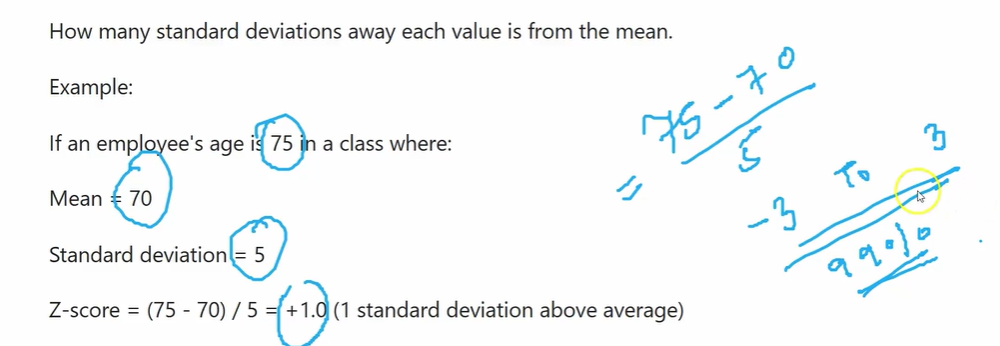

# Min - Max Scaling


In [5]:
minmax_scaler = MinMaxScaler()
scaled_minmax = minmax_scaler.fit_transform(numerical_data)
print('\nScaled Data using MinMaxScaler:\n', pd.DataFrame(scaled_minmax, columns=numerical_data.columns))


Scaled Data using MinMaxScaler:
    Salary   Age
0    0.00  0.00
1    0.25  0.25
2    0.50  0.50
3    0.75  0.75
4    1.00  1.00


In [6]:
numerical_data

,Salary,Age
0,50000,25
1,60000,30
2,70000,35
3,80000,40
4,90000,45


Xscaled = (X - Xmin) / (Xmax - Xmin)

1st value of age -> 
(25 - 25) / (45 - 25) = 0 / 20 = 0

2nd value of age ->
(30 - 25) / (45 - 25) = 5 / 20 = 0.25

3rd value of age ->
(35 - 25) / (45 - 25) = 10 / 20 = 0.50



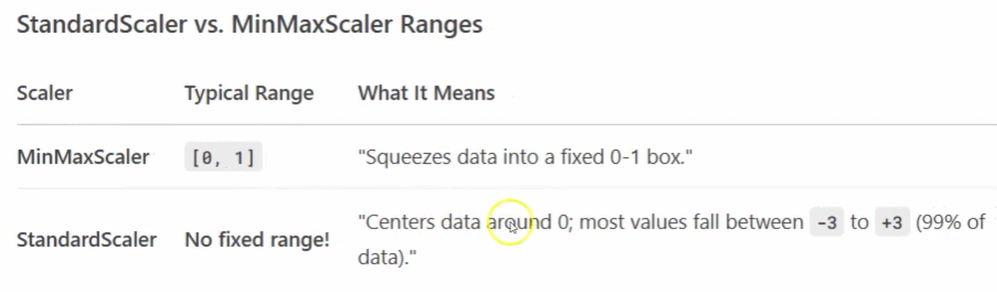

## Encoding Categorical Variables
Converting categorical variables into numerical format for machine learning models.

In [8]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# sample categorical data
cat_data = pd.DataFrame({
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT'],
})
cat_data

,Department
0,HR
1,IT
2,Finance
3,HR
4,IT


# label encoding

In [9]:
label_encoder = LabelEncoder()
cat_data['Department_Label'] = label_encoder.fit_transform(cat_data['Department'])
print("\nLabel Encoded Data:\n", cat_data)


Label Encoded Data:
   Department  Department_Label
0         HR                 1
1         IT                 2
2    Finance                 0
3         HR                 1
4         IT                 2



* `fit_transform()` does two steps at once:
* `fit()`: Learns all unique categories in the column
* `transform()`: Converts each category to a number (e.g., HR $\rightarrow$ 0, IT $\rightarrow$ 1)

# One-hot encoding - alternative to label encoder


In [ ]:
cat_data_ohe = pd.get_dummies(cat_data['Department'], prefix='Dept') # get_dummies is a pandas function that converts categorical variable into dummy/indicator variables.
print('\nOne-Hot Encoded Data:\n', cat_data_ohe)


One-Hot Encoded Data:
    Dept_Finance  Dept_HR  Dept_IT
0         False     True    False
1         False    False     True
2          True    False    False
3         False     True    False
4         False    False     True


in the above code, `pd.get_dummies()` is used to perform one-hot encoding on the 'Department' column. The `prefix='Dept'` argument adds 'Dept_' as a prefix to each new column name.
and it is giving true/false values for each category in the original column. For example, if the original 'Department' column had three unique values: 'HR', 'IT', and 'Finance', the resulting DataFrame will have three new columns: 'Dept_HR', 'Dept_IT', and 'Dept_Finance'. Each row will have a 1 in the column corresponding to its original category and 0s in the other columns.

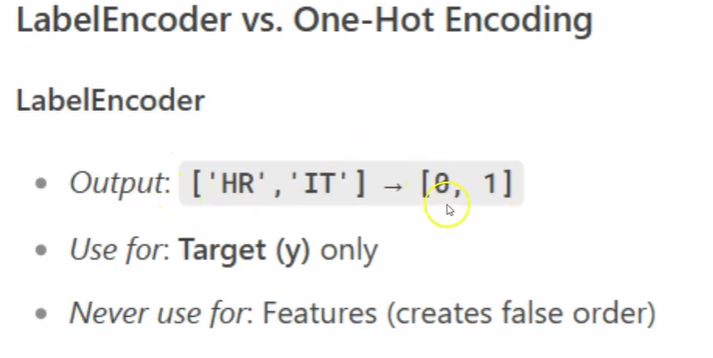
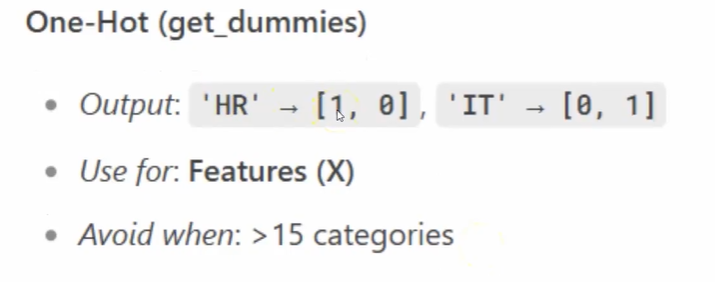


## 3 Normalization

### Normalize data such that row vector magnitudes = 1

### Why Use Normalizer?

### Purpose:

* Scales each row to have a unit magnitude (length = 1) while preserving direction.

### Key Idea:

* Converts row vectors into "pure direction" form by dividing by their Euclidean norm ($\sqrt{(x_1^2 + x_2^2 + \dots)}$)


## When to Use:

* Text data (TF-IDF, word counts) TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that reflects the importance of a word in a document relative to a collection of documents (corpus). It is commonly used in text mining and information retrieval to weigh the significance of terms in documents. The TF-IDF value increases proportionally with the number of times a word appears in a document but is offset by the frequency of the word in the entire corpus, helping to identify words that are more unique and relevant to specific documents.
* Clustering (k-means, cosine similarity) clustering is a machine learning technique that involves grouping similar data points together and different data points all in different groups based on their features or characteristics. K-means is a popular clustering algorithm that partitions data into k clusters by minimizing the variance within each cluster. Cosine similarity is a measure of similarity between two non-zero vectors, often used in clustering to assess the similarity of data points based on their orientation rather than their magnitude.
* Any algorithm sensitive to vector magnitudes but not their lengths (e.g., NLP, recommender systems). NLP (Natural Language Processing) is a field of artificial intelligence that focuses on the interaction between computers and human language. It involves the development of algorithms and models that enable machines to understand, interpret, and generate human language in a way that is both meaningful and useful. NLP encompasses various tasks such as text classification, sentiment analysis, machine translation, named entity recognition, and more, allowing computers to process and analyze large amounts of natural language data effectively.

In [11]:
from sklearn.preprocessing import Normalizer
#example Data
x= np.array([[3.0, 4.0],[1.0, 0.0],[0.0, 8.0]])
print("\nOriginal Data:\n", x)

normalizer = Normalizer()
x_normalized = normalizer.fit_transform(x)
print("\nNormalized Data:\n", x_normalized)



Original Data:
 [[3. 4.]
 [1. 0.]
 [0. 8.]]

Normalized Data:
 [[0.6 0.8]
 [1.  0. ]
 [0.  1. ]]


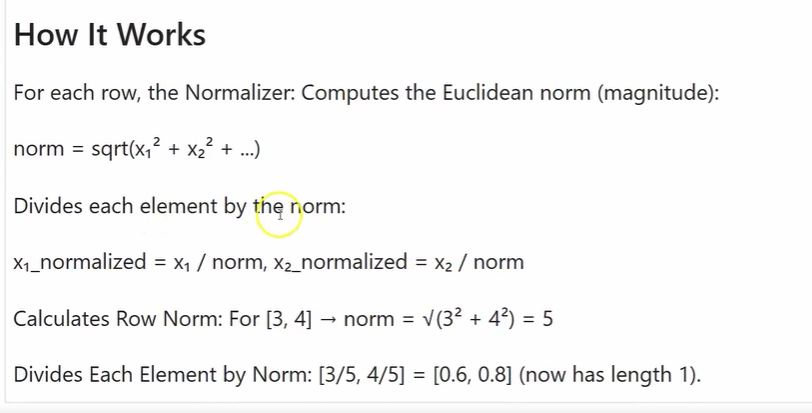

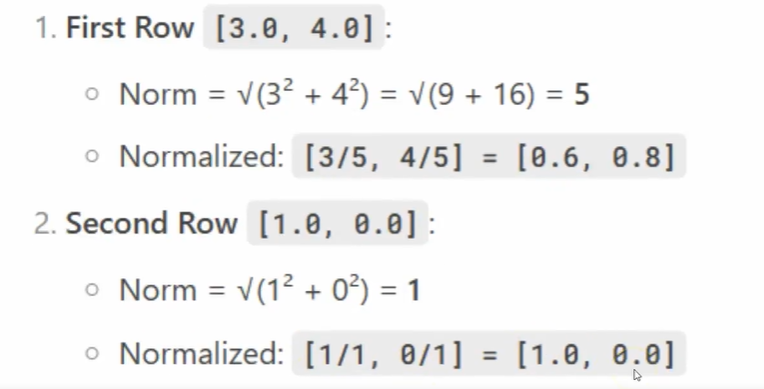
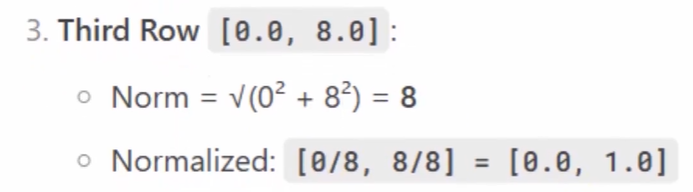
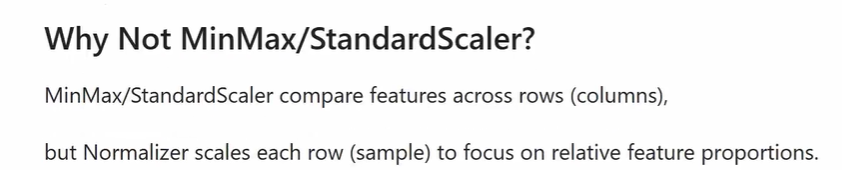


# Case study: Retail Customer Dataset
Scenario: You have a retail customer dataset with income, age, and gender

You want to prepare it for ML model input



In [12]:
raw_data = pd.DataFrame({
    'CustomerID': [101, 102, 103, 104, 105],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female'],
    'Age': [23, 45, 31, 35, 52],
    'Income': [25000, 52000, 38000, 45000, 61000]
})

print("\nOriginal Retail Data:\n", raw_data)


Original Retail Data:
    CustomerID  Gender  Age  Income
0         101    Male   23   25000
1         102  Female   45   52000
2         103  Female   31   38000
3         104    Male   35   45000
4         105  Female   52   61000


In [15]:
# Drop the 'CustomerID' column as it is not needed for ML model input
data = raw_data.drop('CustomerID', axis=1)
print("\nData after dropping CustomerID:\n", data)



Data after dropping CustomerID:
    Gender  Age  Income
0    Male   23   25000
1  Female   45   52000
2  Female   31   38000
3    Male   35   45000
4  Female   52   61000


In [ ]:
# encoding gender column normal method using map function, where Male is encoded as 0 and Female is encoded as 1. This is a common practice in machine learning to convert categorical variables into numerical format for model training.
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
print("\nData after encoding Gender:\n", data)



Data after encoding Gender:
    Gender  Age  Income
0       0   23   25000
1       1   45   52000
2       1   31   38000
3       0   35   45000
4       1   52   61000


In [17]:
# Encoding using label encoding method, where Male is encoded as 0 and Female is encoded as 1. This is a common practice in machine learning to convert categorical variables into numerical format for model training.
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])
print("\nData after encoding Gender using LabelEncoder:\n", data)


Data after encoding Gender using LabelEncoder:
    Gender  Age  Income
0       0   23   25000
1       1   45   52000
2       1   31   38000
3       0   35   45000
4       1   52   61000


In [18]:
# scale age and income ussing minmaxscaler method, which scales the data to a range of [0, 1]. This is a common practice in machine learning to bring all features to the same scale for better model performance.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[['Age', 'Income']])
data[['Age', 'Income']] = scaled
print("\nData after scaling Age and Income using MinMaxScaler:\n", data)


Data after scaling Age and Income using MinMaxScaler:
    Gender       Age    Income
0       0  0.000000  0.000000
1       1  0.758621  0.750000
2       1  0.275862  0.361111
3       0  0.413793  0.555556
4       1  1.000000  1.000000
